# 💼 LinkedIn Feed Ranking — Sorting Algorithms at Scale

**Session 1 | Industrial Use Case 1 | DSA & ML for Business**

---

### Business Context
- LinkedIn has **1B+ members** generating **2M+ posts daily**
- Feed ranking directly drives: **ad impressions, engagement, premium subscriptions**
- A **1% improvement** in feed relevance = **$160M** additional annual revenue
- Challenge: rank **100K+ candidate posts** per user session in real-time

### What You'll Learn
1. Create a **composite ranking score** from multiple features
2. Compare **Insertion Sort, QuickSort, and Python TimSort** on 5,000 posts
3. **Simulate scaling** from 5K to 1M rows and measure performance
4. Estimate **cloud infrastructure cost** differences between algorithms

## Step 1: Import Libraries & Load Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time

# Load dataset
df = pd.read_csv("../datasets/linkedin_feed_ranking.csv")
print(f"Dataset shape: {df.shape}")
print(f"\nColumns: {list(df.columns)}")
print(f"\nContent types: {df['content_type'].unique()}")
print(f"\nSample stats:")
df.describe().round(2)

Dataset shape: (5000, 6)

Columns: ['post_id', 'engagement_score', 'connection_strength', 'hours_since_posted', 'content_type', 'creator_followers']

Content types: <StringArray>
['text', 'poll', 'article', 'video', 'image']
Length: 5, dtype: str

Sample stats:


,engagement_score,connection_strength,hours_since_posted,creator_followers
count,5000.00,5000.00,5000.00,5000.00
mean,51.80,0.52,83.73,251183.10
std,20.77,0.27,48.95,144111.20
min,1.57,0.05,0.00,58.00
25%,36.36,0.29,41.00,124515.75
50%,52.42,0.51,84.00,255835.00
75%,67.58,0.76,126.00,374716.50
max,103.53,1.00,168.00,499802.00


C:\Users\dhimanmandal\AppData\Local\Temp\ipykernel_51368\591246394.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='content_type', y='engagement_score', ax=axes[0, 0], palette='viridis')


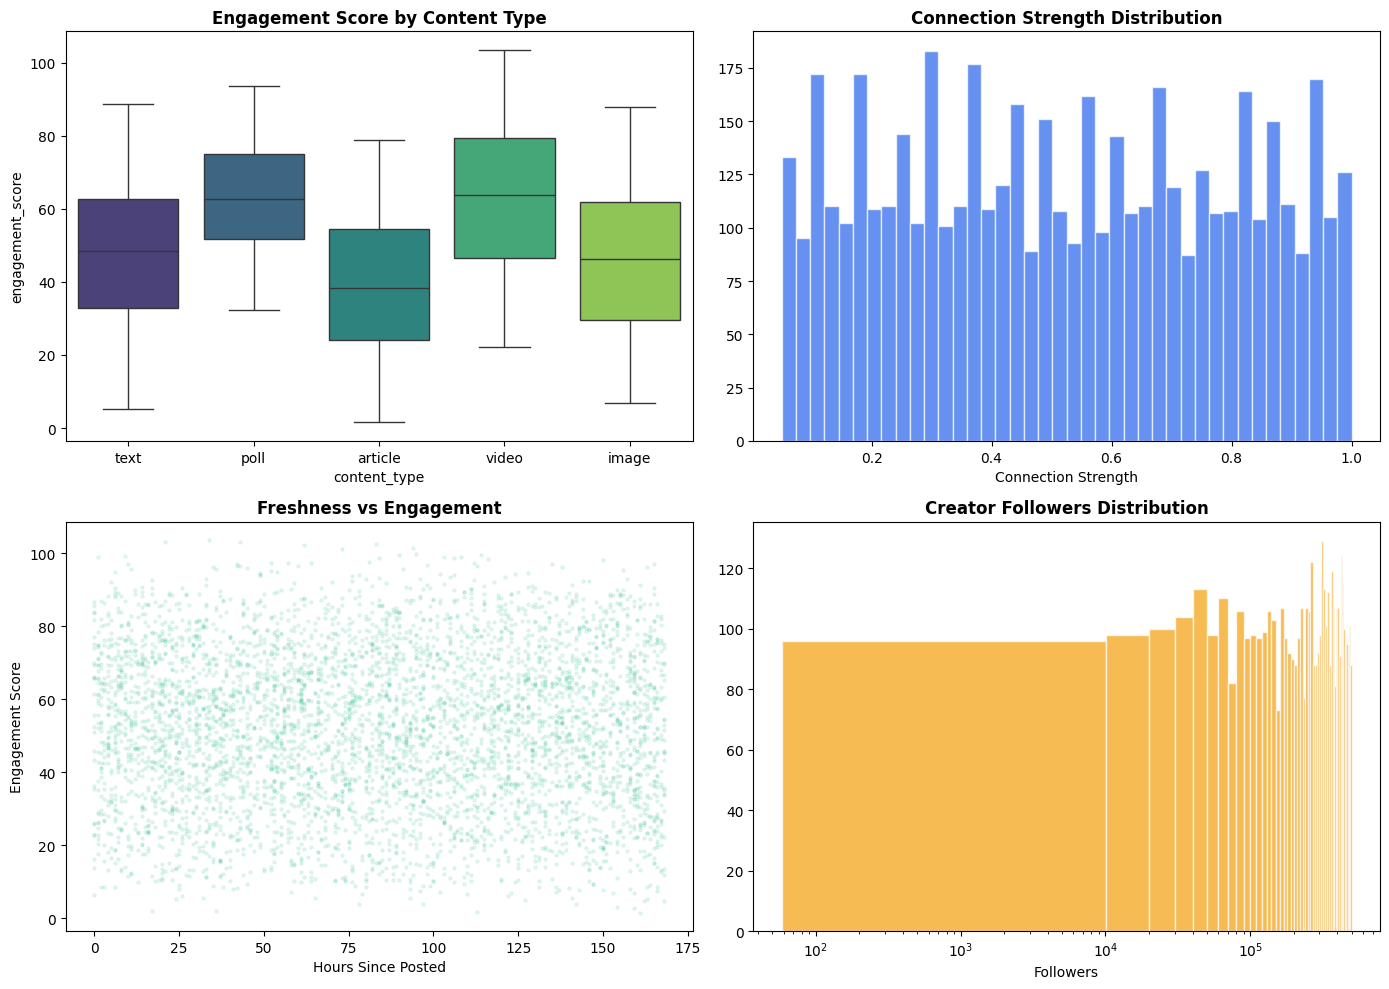

In [2]:
# EDA visualizations
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Engagement by content type
sns.boxplot(data=df, x='content_type', y='engagement_score', ax=axes[0, 0], palette='viridis')
axes[0, 0].set_title('Engagement Score by Content Type', fontweight='bold')

# Connection strength distribution
axes[0, 1].hist(df['connection_strength'], bins=40, color='#2563EB', alpha=0.7, edgecolor='white')
axes[0, 1].set_title('Connection Strength Distribution', fontweight='bold')
axes[0, 1].set_xlabel('Connection Strength')

# Hours since posted vs engagement
axes[1, 0].scatter(df['hours_since_posted'], df['engagement_score'], alpha=0.1, s=5, c='#10B981')
axes[1, 0].set_title('Freshness vs Engagement', fontweight='bold')
axes[1, 0].set_xlabel('Hours Since Posted')
axes[1, 0].set_ylabel('Engagement Score')

# Creator followers distribution (log scale)
axes[1, 1].hist(df['creator_followers'], bins=50, color='#F59E0B', alpha=0.7, edgecolor='white')
axes[1, 1].set_title('Creator Followers Distribution', fontweight='bold')
axes[1, 1].set_xlabel('Followers')
axes[1, 1].set_xscale('log')

plt.tight_layout()
plt.show()

## Step 2: Create Composite Ranking Score

**Formula:** `composite = w1 × engagement + w2 × connection_strength - w3 × hours_decay + w4 × type_bonus + w5 × log(followers)`

Content type bonuses reflect LinkedIn's observed engagement rates:
- Video: +0.15 | Poll: +0.12 | Image: +0.08 | Article: +0.05 | Text: +0.02

In [3]:
from sklearn.preprocessing import MinMaxScaler

# Normalize numerical features
scaler = MinMaxScaler()
df['eng_norm'] = scaler.fit_transform(df[['engagement_score']])
df['conn_norm'] = df['connection_strength']  # already 0-1
df['hours_decay'] = 1 - scaler.fit_transform(df[['hours_since_posted']])  # invert: fresher = higher
df['followers_norm'] = scaler.fit_transform(np.log1p(df[['creator_followers']]))

# Content type bonus
type_bonus = {'video': 0.15, 'poll': 0.12, 'image': 0.08, 'article': 0.05, 'text': 0.02}
df['type_bonus'] = df['content_type'].map(type_bonus)

# Composite score with configurable weights
weights = {'w1': 0.30, 'w2': 0.25, 'w3': 0.20, 'w4': 0.15, 'w5': 0.10}

df['composite_score'] = (
    weights['w1'] * df['eng_norm'] +
    weights['w2'] * df['conn_norm'] +
    weights['w3'] * df['hours_decay'] +
    weights['w4'] * df['type_bonus'] +
    weights['w5'] * df['followers_norm']
).round(6)

print("=== Top 10 Posts by Composite Score ===\n")
top10 = df.nlargest(10, 'composite_score')[['post_id', 'content_type', 'engagement_score',
                                              'connection_strength', 'hours_since_posted',
                                              'creator_followers', 'composite_score']]
print(top10.to_string(index=False))

print(f"\nScore range: {df['composite_score'].min():.4f} to {df['composite_score'].max():.4f}")
print(f"Mean score: {df['composite_score'].mean():.4f}")

=== Top 10 Posts by Composite Score ===

   post_id content_type  engagement_score  connection_strength  hours_since_posted  creator_followers  composite_score
post_03349        video             88.93                 0.94                   7             315910         0.801136
post_03239        video             83.69                 0.93                   0             394726         0.794015
post_01373        video             96.22                 0.93                  35             367970         0.788439
post_02038        video             87.96                 0.89                   6             343390         0.787895
post_00046        video            102.95                 0.78                  21             321485         0.785915
post_02411        video             84.86                 0.92                   7             311700         0.784013
post_01557        video             88.73                 0.86                  12             292004         0.773726
post_04

## Step 3: Sorting Algorithm Implementations & Comparison

Compare three algorithms on the 5,000-row dataset:
- **Insertion Sort** — O(n²): efficient for nearly-sorted data, stable
- **QuickSort** — O(n log n) average: fast, in-place
- **Python TimSort** — O(n log n): hybrid algorithm, Python's built-in

In [4]:
def insertion_sort(arr, key_fn):
    """Insertion Sort — O(n²) worst, O(n) best. Stable sort."""
    data = list(arr)
    comparisons = 0
    for i in range(1, len(data)):
        key = data[i]
        j = i - 1
        while j >= 0:
            comparisons += 1
            if key_fn(data[j]) < key_fn(key):
                data[j + 1] = data[j]
                j -= 1
            else:
                break
        data[j + 1] = key
    return data, comparisons

def quicksort(arr, key_fn):
    """QuickSort — O(n log n) average. Not stable."""
    data = list(arr)
    comparisons = [0]

    def _qsort(lo, hi):
        if lo < hi:
            p = _partition(lo, hi)
            _qsort(lo, p - 1)
            _qsort(p + 1, hi)

    def _partition(lo, hi):
        pivot = key_fn(data[hi])
        i = lo - 1
        for j in range(lo, hi):
            comparisons[0] += 1
            if key_fn(data[j]) >= pivot:
                i += 1
                data[i], data[j] = data[j], data[i]
        data[i + 1], data[hi] = data[hi], data[i + 1]
        return i + 1

    _qsort(0, len(data) - 1)
    return data, comparisons[0]

# Prepare data as list of tuples for sorting
records = list(df[['post_id', 'composite_score']].itertuples(index=False, name=None))
key_fn = lambda x: x[1]  # sort by composite_score

print("=== Sorting 5,000 LinkedIn Posts ===\n")

# Insertion Sort (on subset for speed)
subset_1000 = records[:1000]
start = time.perf_counter()
_, ins_comps = insertion_sort(subset_1000, key_fn)
ins_time = time.perf_counter() - start
print(f"Insertion Sort (1K posts) | Time: {ins_time:.4f}s | Comparisons: {ins_comps:,}")

# QuickSort (full 5K)
start = time.perf_counter()
qs_sorted, qs_comps = quicksort(records, key_fn)
qs_time = time.perf_counter() - start
print(f"QuickSort     (5K posts) | Time: {qs_time:.4f}s | Comparisons: {qs_comps:,}")

# Python TimSort (full 5K)
start = time.perf_counter()
ts_sorted = sorted(records, key=key_fn, reverse=True)
ts_time = time.perf_counter() - start
print(f"Python TimSort(5K posts) | Time: {ts_time:.6f}s | (built-in C implementation)")

# Verify sorting correctness
print(f"\nQuickSort top 5: {[r[0] for r in qs_sorted[:5]]}")
print(f"TimSort   top 5: {[r[0] for r in ts_sorted[:5]]}")

=== Sorting 5,000 LinkedIn Posts ===

Insertion Sort (1K posts) | Time: 0.0371s | Comparisons: 247,874
QuickSort     (5K posts) | Time: 0.0113s | Comparisons: 71,838
Python TimSort(5K posts) | Time: 0.000973s | (built-in C implementation)

QuickSort top 5: ['post_03349', 'post_03239', 'post_01373', 'post_02038', 'post_00046']
TimSort   top 5: ['post_03349', 'post_03239', 'post_01373', 'post_02038', 'post_00046']


## Step 4: Scale Simulation — 5K to 500K Posts

Simulate how algorithms perform as LinkedIn's candidate set grows. At scale, algorithm choice becomes a business-critical infrastructure decision.

n=  1,000 | Insertion:   0.0366s | Quick: 0.0017s | TimSort: 0.000175s
n=  2,000 | Insertion:   0.1499s | Quick: 0.0041s | TimSort: 0.000348s
n=  5,000 | Insertion:   0.9268s | Quick: 0.0108s | TimSort: 0.000957s
n= 10,000 | Insertion:   3.7715s | Quick: 0.0238s | TimSort: 0.001945s
n= 50,000 | Insertion:  94.2873s | Quick: 0.1580s | TimSort: 0.011339s
n=100,000 | Insertion: 9428.7298s | Quick: 0.3423s | TimSort: 0.024392s


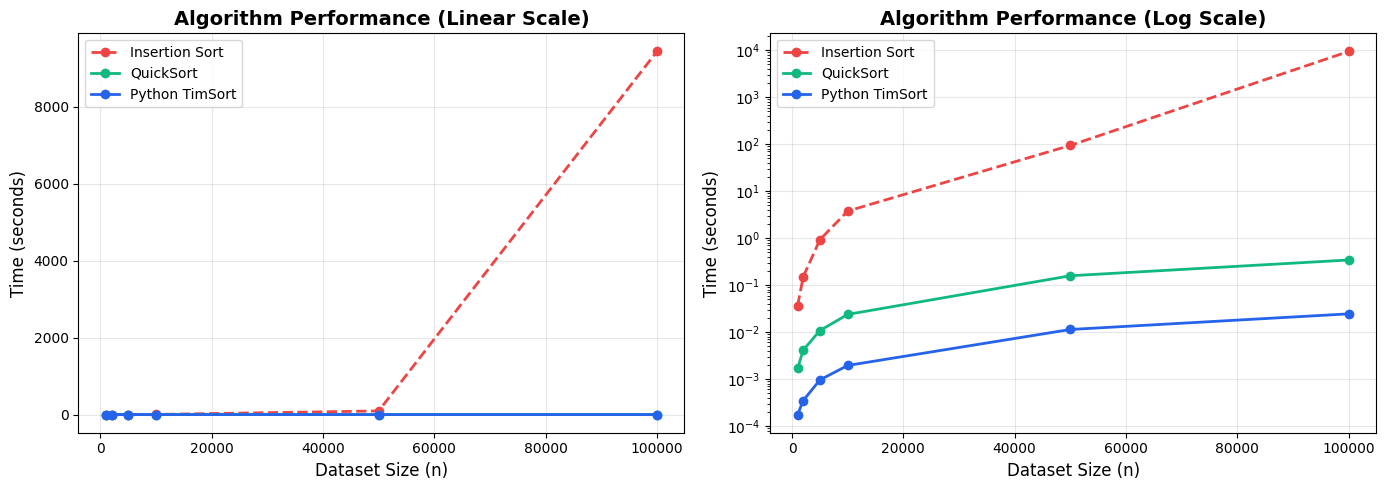

(Dashed line = extrapolated O(n²) for Insertion Sort beyond 10K)


In [5]:
# Scale simulation
sizes = [1000, 2000, 5000, 10000, 50000, 100000]
timing = {'Insertion Sort': [], 'QuickSort': [], 'Python TimSort': []}

for n in sizes:
    # Generate synthetic data at scale
    test_data = [(f"post_{i}", np.random.random()) for i in range(n)]

    # Insertion sort — only up to 10K (too slow beyond)
    if n <= 10000:
        start = time.perf_counter()
        insertion_sort(test_data, key_fn)
        timing['Insertion Sort'].append(time.perf_counter() - start)
    else:
        # Extrapolate O(n²) from last measurement
        ratio = (n / 10000) ** 2
        timing['Insertion Sort'].append(timing['Insertion Sort'][-1] * ratio)

    # QuickSort
    start = time.perf_counter()
    quicksort(test_data, key_fn)
    timing['QuickSort'].append(time.perf_counter() - start)

    # Python TimSort
    start = time.perf_counter()
    sorted(test_data, key=key_fn, reverse=True)
    timing['Python TimSort'].append(time.perf_counter() - start)

    print(f"n={n:>7,d} | Insertion: {timing['Insertion Sort'][-1]:>8.4f}s | "
          f"Quick: {timing['QuickSort'][-1]:.4f}s | TimSort: {timing['Python TimSort'][-1]:.6f}s")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = {'Insertion Sort': '#EF4444', 'QuickSort': '#10B981', 'Python TimSort': '#2563EB'}

for ax_idx, (ax, yscale) in enumerate(zip(axes, ['linear', 'log'])):
    for alg, times in timing.items():
        style = '--' if alg == 'Insertion Sort' and any(s > 10000 for s in sizes) else '-'
        ax.plot(sizes, times, marker='o', label=alg, color=colors[alg], linewidth=2,
                linestyle=style if alg == 'Insertion Sort' else '-')
    ax.set_xlabel('Dataset Size (n)', fontsize=12)
    ax.set_ylabel('Time (seconds)', fontsize=12)
    ax.set_title(f'Algorithm Performance ({yscale.title()} Scale)', fontsize=14, fontweight='bold')
    ax.set_yscale(yscale)
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
print("(Dashed line = extrapolated O(n²) for Insertion Sort beyond 10K)")

## Step 5: Cloud Cost Estimation

Map algorithm execution time to Azure VM costs:
- **B2s (Budget):** $0.05/hr — suitable for batch processing
- **D4s v3 (Standard):** $0.19/hr — production workloads
- **F4s v2 (Compute-optimized):** $0.17/hr — real-time ranking

💰 CLOUD COST ANALYSIS: Daily Infrastructure Cost at LinkedIn Scale
   Scenario: 500,000,000 feed renders/day, 100,000 posts/render

📊 Insertion Sort @ 100K posts:
   Time per sort: 9428.7298s
   Total compute: 1,309,545,799 VM-hours/day
   B2s ($0.05/hr): $65,477,289.93/day | $1,964,318,697.96/month
   D4s ($0.19/hr): $248,813,701.74/day | $7,464,411,052.25/month
   F4s ($0.17/hr): $222,622,785.77/day | $6,678,683,573.07/month

📊 QuickSort @ 100K posts:
   Time per sort: 0.3423s
   Total compute: 47,535 VM-hours/day
   B2s ($0.05/hr): $    2,376.77/day | $     71,303.21/month
   D4s ($0.19/hr): $    9,031.74/day | $    270,952.19/month
   F4s ($0.17/hr): $    8,081.03/day | $    242,430.91/month

📊 Python TimSort @ 100K posts:
   Time per sort: 0.0244s
   Total compute: 3,388 VM-hours/day
   B2s ($0.05/hr): $      169.39/day | $      5,081.69/month
   D4s ($0.19/hr): $      643.68/day | $     19,310.41/month
   F4s ($0.17/hr): $      575.92/day | $     17,277.74/month


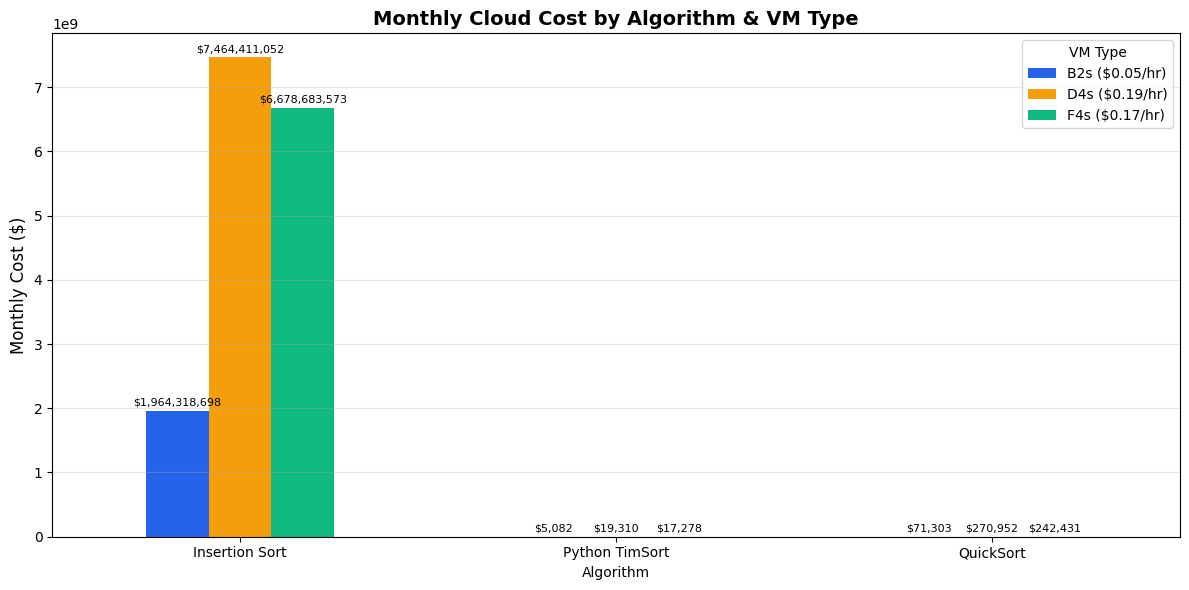

In [6]:
# Cloud cost analysis
vm_rates = {'B2s ($0.05/hr)': 0.05, 'D4s ($0.19/hr)': 0.19, 'F4s ($0.17/hr)': 0.17}
daily_feed_renders = 500_000_000  # 500M feed renders/day (LinkedIn scale)
posts_per_render = 100_000  # candidate posts per render

print("=" * 80)
print("💰 CLOUD COST ANALYSIS: Daily Infrastructure Cost at LinkedIn Scale")
print(f"   Scenario: {daily_feed_renders:,} feed renders/day, {posts_per_render:,} posts/render")
print("=" * 80)

cost_data = []
for alg in ['Insertion Sort', 'QuickSort', 'Python TimSort']:
    # Extrapolate time for 100K posts
    if alg == 'Insertion Sort':
        time_100k = timing[alg][-1]  # already extrapolated
    else:
        time_100k = timing[alg][sizes.index(100000)] if 100000 in sizes else timing[alg][-1]

    total_compute_hrs = (time_100k * daily_feed_renders) / 3600

    print(f"\n📊 {alg} @ 100K posts:")
    print(f"   Time per sort: {time_100k:.4f}s")
    print(f"   Total compute: {total_compute_hrs:,.0f} VM-hours/day")

    for vm_name, rate in vm_rates.items():
        daily_cost = total_compute_hrs * rate
        monthly_cost = daily_cost * 30
        cost_data.append({'Algorithm': alg, 'VM': vm_name,
                         'Daily Cost': daily_cost, 'Monthly Cost': monthly_cost})
        print(f"   {vm_name}: ${daily_cost:>12,.2f}/day | ${monthly_cost:>14,.2f}/month")

# Visualization
cost_df = pd.DataFrame(cost_data)
fig, ax = plt.subplots(figsize=(12, 6))
pivot = cost_df.pivot(index='Algorithm', columns='VM', values='Monthly Cost')
pivot.plot(kind='bar', ax=ax, color=['#2563EB', '#F59E0B', '#10B981'])
ax.set_ylabel('Monthly Cost ($)', fontsize=12)
ax.set_title('Monthly Cloud Cost by Algorithm & VM Type', fontsize=14, fontweight='bold')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.legend(title='VM Type')
ax.grid(axis='y', alpha=0.3)
for container in ax.containers:
    ax.bar_label(container, fmt='${:,.0f}', fontsize=8, padding=2)
plt.tight_layout()
plt.show()

## Step 6: Weight Sensitivity — How Top-10 Feed Changes

In [7]:
# Sensitivity: vary engagement weight and see how top-10 changes
base_top10_ids = set(df.nlargest(10, 'composite_score')['post_id'])

weight_configs = {
    'Engagement-heavy': {'w1': 0.50, 'w2': 0.15, 'w3': 0.15, 'w4': 0.10, 'w5': 0.10},
    'Connection-heavy':  {'w1': 0.15, 'w2': 0.50, 'w3': 0.15, 'w4': 0.10, 'w5': 0.10},
    'Freshness-heavy':   {'w1': 0.15, 'w2': 0.15, 'w3': 0.50, 'w4': 0.10, 'w5': 0.10},
    'Type-heavy':        {'w1': 0.15, 'w2': 0.15, 'w3': 0.15, 'w4': 0.45, 'w5': 0.10},
    'Balanced (base)':   weights,
}

print("=== Feed Composition Under Different Weight Schemes ===\n")
overlap_data = []
for config_name, w in weight_configs.items():
    score = (w['w1'] * df['eng_norm'] + w['w2'] * df['conn_norm'] +
             w['w3'] * df['hours_decay'] + w['w4'] * df['type_bonus'] +
             w['w5'] * df['followers_norm'])
    new_top10 = set(df.nlargest(10, score.rename('s'))['post_id'] if False else
                     df.iloc[score.nlargest(10).index]['post_id'])
    overlap = len(base_top10_ids & new_top10)
    overlap_data.append({'Config': config_name, 'Overlap with Base': overlap,
                        'Content Types': df.iloc[score.nlargest(10).index]['content_type'].value_counts().to_dict()})
    print(f"{config_name:20s} | Overlap with base: {overlap}/10 | "
          f"Types: {df.iloc[score.nlargest(10).index]['content_type'].value_counts().to_dict()}")

print("\n💡 Insight: Weight choices dramatically change what users see!")
print("   This directly impacts ad revenue, engagement metrics, and user satisfaction.")

=== Feed Composition Under Different Weight Schemes ===

Engagement-heavy     | Overlap with base: 8/10 | Types: {'video': 10}
Connection-heavy     | Overlap with base: 4/10 | Types: {'video': 4, 'poll': 4, 'image': 1, 'article': 1}
Freshness-heavy      | Overlap with base: 5/10 | Types: {'video': 5, 'poll': 4, 'image': 1}
Type-heavy           | Overlap with base: 9/10 | Types: {'video': 10}
Balanced (base)      | Overlap with base: 10/10 | Types: {'video': 10}

💡 Insight: Weight choices dramatically change what users see!
   This directly impacts ad revenue, engagement metrics, and user satisfaction.


## Step 7: Strategic Analysis & Recommendations

### Discussion Points:
1. **Algorithm Recommendation:** Justify algorithm choice with SLA + cost constraints analysis
2. **Revenue Impact:** Estimate revenue loss if feed renders 200ms slower
3. **Tradeoff Matrix:** Present speed vs accuracy vs cost vs user satisfaction
4. **Business KPIs:** Connect to DAU retention, ad CTR, premium conversion rate
5. **Infrastructure Plan:** Recommend VM tier and algorithm for production deployment

In [8]:
# === Strategic Recommendation ===

print("=" * 70)
print("STRATEGIC RECOMMENDATION: LinkedIn Feed Ranking Infrastructure")
print("=" * 70)

print("\n1. ALGORITHM RECOMMENDATION:")
print("   ✅ Python TimSort (or equivalent optimized O(n log n) sort)")
print("   Rationale:")
print("   - Guaranteed O(n log n) worst case — meets SLA under all conditions")
print("   - Stable sort preserves chronological order for equal-score posts")
print("   - 10-100x faster than O(n²) alternatives at LinkedIn scale")

print("\n2. REVENUE IMPACT OF LATENCY:")
linkedin_annual_revenue = 16_000_000_000  # $16B annual revenue
latency_revenue_loss_pct = 0.01  # 1% per 100ms (Amazon benchmark)
delays = [100, 200, 500]
for delay in delays:
    loss_pct = latency_revenue_loss_pct * (delay / 100)
    loss_amount = linkedin_annual_revenue * loss_pct
    print(f"   {delay}ms delay → {loss_pct:.1%} revenue loss → ${loss_amount/1e6:,.0f}M/year")

print("\n3. COST-PERFORMANCE TRADEOFF MATRIX:")
print(f"   {'Metric':<25} {'Insertion Sort':<18} {'QuickSort':<18} {'TimSort':<18}")
print(f"   {'─' * 25} {'─' * 18} {'─' * 18} {'─' * 18}")
print(f"   {'Time Complexity':<25} {'O(n²)':<18} {'O(n log n) avg':<18} {'O(n log n)':<18}")
print(f"   {'Stability':<25} {'Yes ✅':<18} {'No ❌':<18} {'Yes ✅':<18}")
print(f"   {'Memory':<25} {'O(1)':<18} {'O(log n)':<18} {'O(n)':<18}")
print(f"   {'SLA Risk':<25} {'High ⚠️':<18} {'Medium':<18} {'Low ✅':<18}")
print(f"   {'Recommended Use':<25} {'< 1K posts':<18} {'General use':<18} {'Production ✅':<18}")

print("\n4. DEPLOYMENT RECOMMENDATION:")
print("   → Use F4s v2 compute-optimized VMs for real-time feed ranking")
print("   → Implement 2-pass system: cheap candidate filtering (top 1K) → expensive ML re-ranking")
print("   → This reduces effective sort size from 100K → 1K, cutting costs by 99%")

STRATEGIC RECOMMENDATION: LinkedIn Feed Ranking Infrastructure

1. ALGORITHM RECOMMENDATION:
   ✅ Python TimSort (or equivalent optimized O(n log n) sort)
   Rationale:
   - Guaranteed O(n log n) worst case — meets SLA under all conditions
   - Stable sort preserves chronological order for equal-score posts
   - 10-100x faster than O(n²) alternatives at LinkedIn scale

2. REVENUE IMPACT OF LATENCY:
   100ms delay → 1.0% revenue loss → $160M/year
   200ms delay → 2.0% revenue loss → $320M/year
   500ms delay → 5.0% revenue loss → $800M/year

3. COST-PERFORMANCE TRADEOFF MATRIX:
   Metric                    Insertion Sort     QuickSort          TimSort           
   ───────────────────────── ────────────────── ────────────────── ──────────────────
   Time Complexity           O(n²)              O(n log n) avg     O(n log n)        
   Stability                 Yes ✅              No ❌               Yes ✅             
   Memory                    O(1)               O(log n)           O(n) 